In [1]:
# import libraries
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import MultipleLocator
import cmocean
import xarray as xr
import numpy as np

In [2]:
# projection parameters
PROJ         = ccrs.NorthPolarStereo(central_longitude=-10)
LAND_50m     = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                            edgecolor = 'k',
                                            facecolor = cfeature.COLORS['land'])

DATA_CRS = ccrs.PlateCarree()   # CRS the lon/lat data are stored in
MAP_PROJ  = ccrs.PlateCarree()  # Map projection for plotting

# Optional regional extent [lon_min, lon_max, lat_min, lat_max]
EXTENT = [-18, 41, 66, 90]

In [3]:
# text and label parameters
label_style = {'size': 14, 'color': 'gray'}
title_fontsize = 18
axis_fontsize = 14

In [4]:
# colors
COLORS = {
    0: '#0090a8',  
    1: '#cc6f28',  
    2: "#377eb8",  
    3: 'k'           
}

In [5]:
# define variables and their parameters for plotting
VAR_CFG = {
    "ssh": {
        "nc_name":   "zeta",          # try 'ssh', 'eta', 'zeta'
        "is_3d":     False,
        "long_name": "Sea surface height",
        "units":     "m",
        "cmap":      cmocean.cm.balance,
        "vmin":      -1.5,
        "vmax":       1.5,
    },
    "salt": {
        "nc_name":   "salt",           # try 'salt', 'salinity', 'S'
        "is_3d":     True,
        "long_name": "Salinity",
        "units":     "PSU",
        "cmap":      cmocean.cm.haline,
        "vmin":      30.0,
        "vmax":      38.0,
    },
    "temp": {
        "nc_name":   "temperature",       # try 'temp', 'temperature', 'T'
        "is_3d":     True,
        "long_name": "Temperature",
        "units":     "°C",
        "cmap":      cmocean.cm.thermal,
        "vmin":       0.0,
        "vmax":      32.0,
    },
}

LON_NAME  = "lon"   # try 'longitude', 'nav_lon', 'x'
LAT_NAME  = "lat"   # try 'latitude',  'nav_lat', 'y'
TIME_NAME = "time"  # try 'ocean_time'

In [6]:
# read data from URL
base = "https://thredds.met.no"
url_opendap = base + "/thredds/dodsC/fou-hi/barents_eps_surface/2026/04/21/T00Z/barents_sfc_20260421T00Zm05.nc"


In [7]:
ds = xr.open_dataset(url_opendap, engine="netcdf4")
print(ds)

<xarray.Dataset> Size: 4GB
Dimensions:                  (s_rho: 42, s_w: 43, X: 739, Y: 949, depth: 1,
                              time: 97)
Coordinates:
  * X                        (X) float32 3kB 2.786e+05 2.811e+05 ... 2.124e+06
  * Y                        (Y) float32 4kB -8.979e+05 -8.954e+05 ... 1.472e+06
  * depth                    (depth) float64 8B 0.0
  * time                     (time) datetime64[ns] 776B 2026-04-21 ... 2026-0...
    lat                      (Y, X) float64 6MB ...
    lon                      (Y, X) float64 6MB ...
Dimensions without coordinates: s_rho, s_w
Data variables: (12/22)
    Cs_r                     (s_rho) float64 336B ...
    Cs_w                     (s_w) float64 344B ...
    forecast_hour            (time) int32 388B ...
    forecast_reference_time  datetime64[ns] 8B ...
    hc                       float64 8B ...
    projection_lambert       int32 4B ...
    ...                       ...
    sea_mask                 (Y, X) float64 6MB ...


In [8]:
# Select variable to plot from config
var = "ssh"
cfg = VAR_CFG[var]

# Validate requested variable exists in dataset
if cfg["nc_name"] not in ds.variables:
    print("Missing variable:", cfg["nc_name"])
    print("Available variables:", list(ds.variables))
    raise KeyError(cfg["nc_name"])

da = ds[cfg["nc_name"]]


# Select first time step if present
if TIME_NAME in da.dims:
    da = da.isel({TIME_NAME: 0})
elif "ocean_time" in da.dims:
    da = da.isel(ocean_time=0)


# Select first depth/sigma level for 3D variables
if cfg["is_3d"]:
    for dname in ["depth", "s_rho", "lev", "z"]:
        if dname in da.dims:
            da = da.isel({dname: 0})
            break

field = da.squeeze()
lon = ds[LON_NAME]
lat = ds[LAT_NAME]

print("Plotting:", var, "->", cfg["nc_name"], "shape:", field.shape)

Plotting: ssh -> zeta shape: (949, 739)


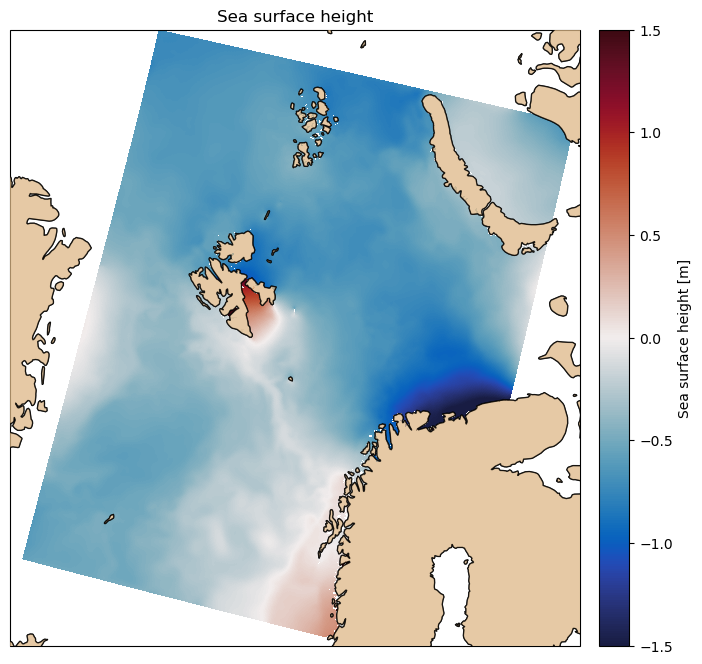

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8), subplot_kw={"projection": PROJ})

if EXTENT is not None:
    ax.set_extent(EXTENT, crs=MAP_PROJ)

ax.add_feature(LAND_50m, facecolor="burlywood", alpha=0.75, zorder=101)
ax.coastlines(resolution="50m", linewidth=0.7)

im = ax.pcolormesh(
    lon, lat, field,
    cmap=cfg["cmap"],
    vmin=cfg["vmin"],
    vmax=cfg["vmax"],
    transform=DATA_CRS,
    shading="auto"
)

ax.set_title(cfg["long_name"])

# Vertical colorbar on the right side
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    pad=0.02,      # distance from subplot
    fraction=0.05  # colorbar width
)
cbar.set_label(f"{cfg['long_name']} [{cfg['units']}]")

plt.show()

In [10]:
# Time series at one point
var = "temp"
cfg = VAR_CFG[var]

target_lon = 20.0
target_lat = 74.0

da = ds[cfg["nc_name"]]


# Keep time dimension, reduce vertical dimension only
if cfg["is_3d"]:
    for dname in ["depth", "s_rho", "lev", "z"]:
        if dname in da.dims:
            da = da.isel({dname: 0})
            break

# 2D lon/lat case
if lon.ndim == 2 and lat.ndim == 2:
    dist2 = (lon - target_lon) ** 2 + (lat - target_lat) ** 2
    j, i = np.unravel_index(np.nanargmin(dist2.values), dist2.shape)

    ydim, xdim = lon.dims
    if ydim not in da.dims or xdim not in da.dims:
        raise ValueError(
            f"Coordinate dims {lon.dims} not found in data dims {da.dims}"
        )

    ts = da.isel({ydim: j, xdim: i})
    pt_lon = float(lon.values[j, i])
    pt_lat = float(lat.values[j, i])

# 1D lon/lat case
elif lon.ndim == 1 and lat.ndim == 1:
    xdim = lon.dims[0]
    ydim = lat.dims[0]

    i = int(np.nanargmin(np.abs(lon.values - target_lon)))
    j = int(np.nanargmin(np.abs(lat.values - target_lat)))

    if xdim not in da.dims or ydim not in da.dims:
        raise ValueError(
            f"Coordinate dims {(ydim, xdim)} not found in data dims {da.dims}"
        )

    ts = da.isel({xdim: i, ydim: j})
    pt_lon = float(lon.values[i])
    pt_lat = float(lat.values[j])

else:
    raise ValueError("Unsupported coordinate layout for lon/lat")

# Final validation: must be 1D in time only
time_candidates = [TIME_NAME, "ocean_time", "time"]
time_dim = next((name for name in time_candidates if name in ts.dims), None)

if time_dim is None:
    raise ValueError(f"No time dimension found in extracted series. Dims: {ts.dims}")

other_dims = [dim for dim in ts.dims if dim != time_dim]
if other_dims:
    raise ValueError(f"Point extraction failed. Remaining non-time dims: {other_dims}, shape={ts.shape}")

print(f"Nearest point: lon={pt_lon:.3f}, lat={pt_lat:.3f}")
print("Time series dims:", ts.dims, "shape:", ts.shape)

Nearest point: lon=20.016, lat=73.992
Time series dims: ('time',) shape: (97,)


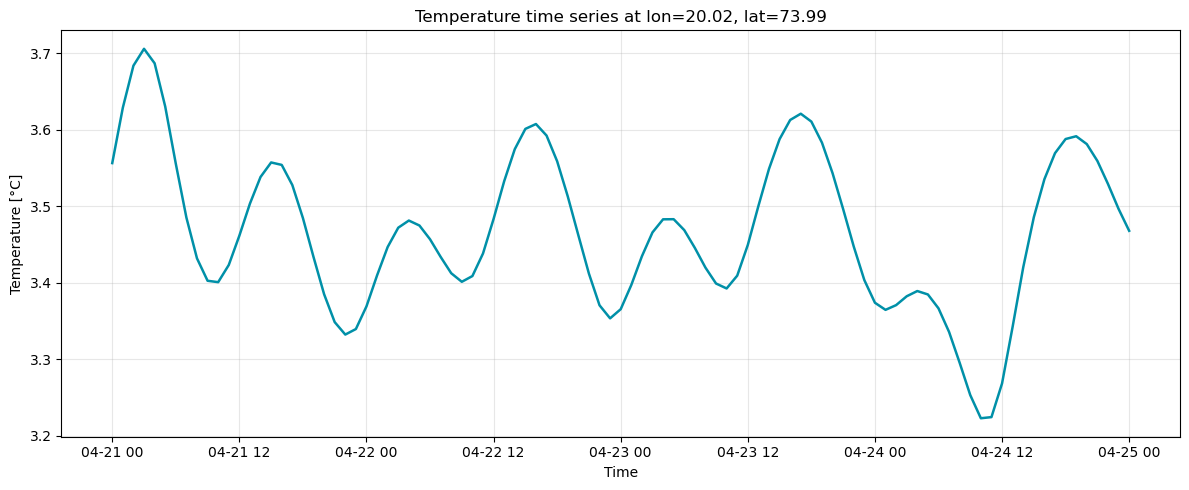

In [11]:
time_dim = next((name for name in [TIME_NAME, "ocean_time", "time"] if name in ts.dims), None)
if time_dim is None:
    raise ValueError("No time dimension found in selected time series")

time_values = ds[time_dim].values

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(time_values, ts.values, color=COLORS[0], linewidth=1.8)
ax.set_title(f"{cfg['long_name']} time series at lon={pt_lon:.2f}, lat={pt_lat:.2f}")
ax.set_xlabel("Time")
ax.set_ylabel(f"{cfg['long_name']} [{cfg['units']}]")
ax.grid(True, alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()